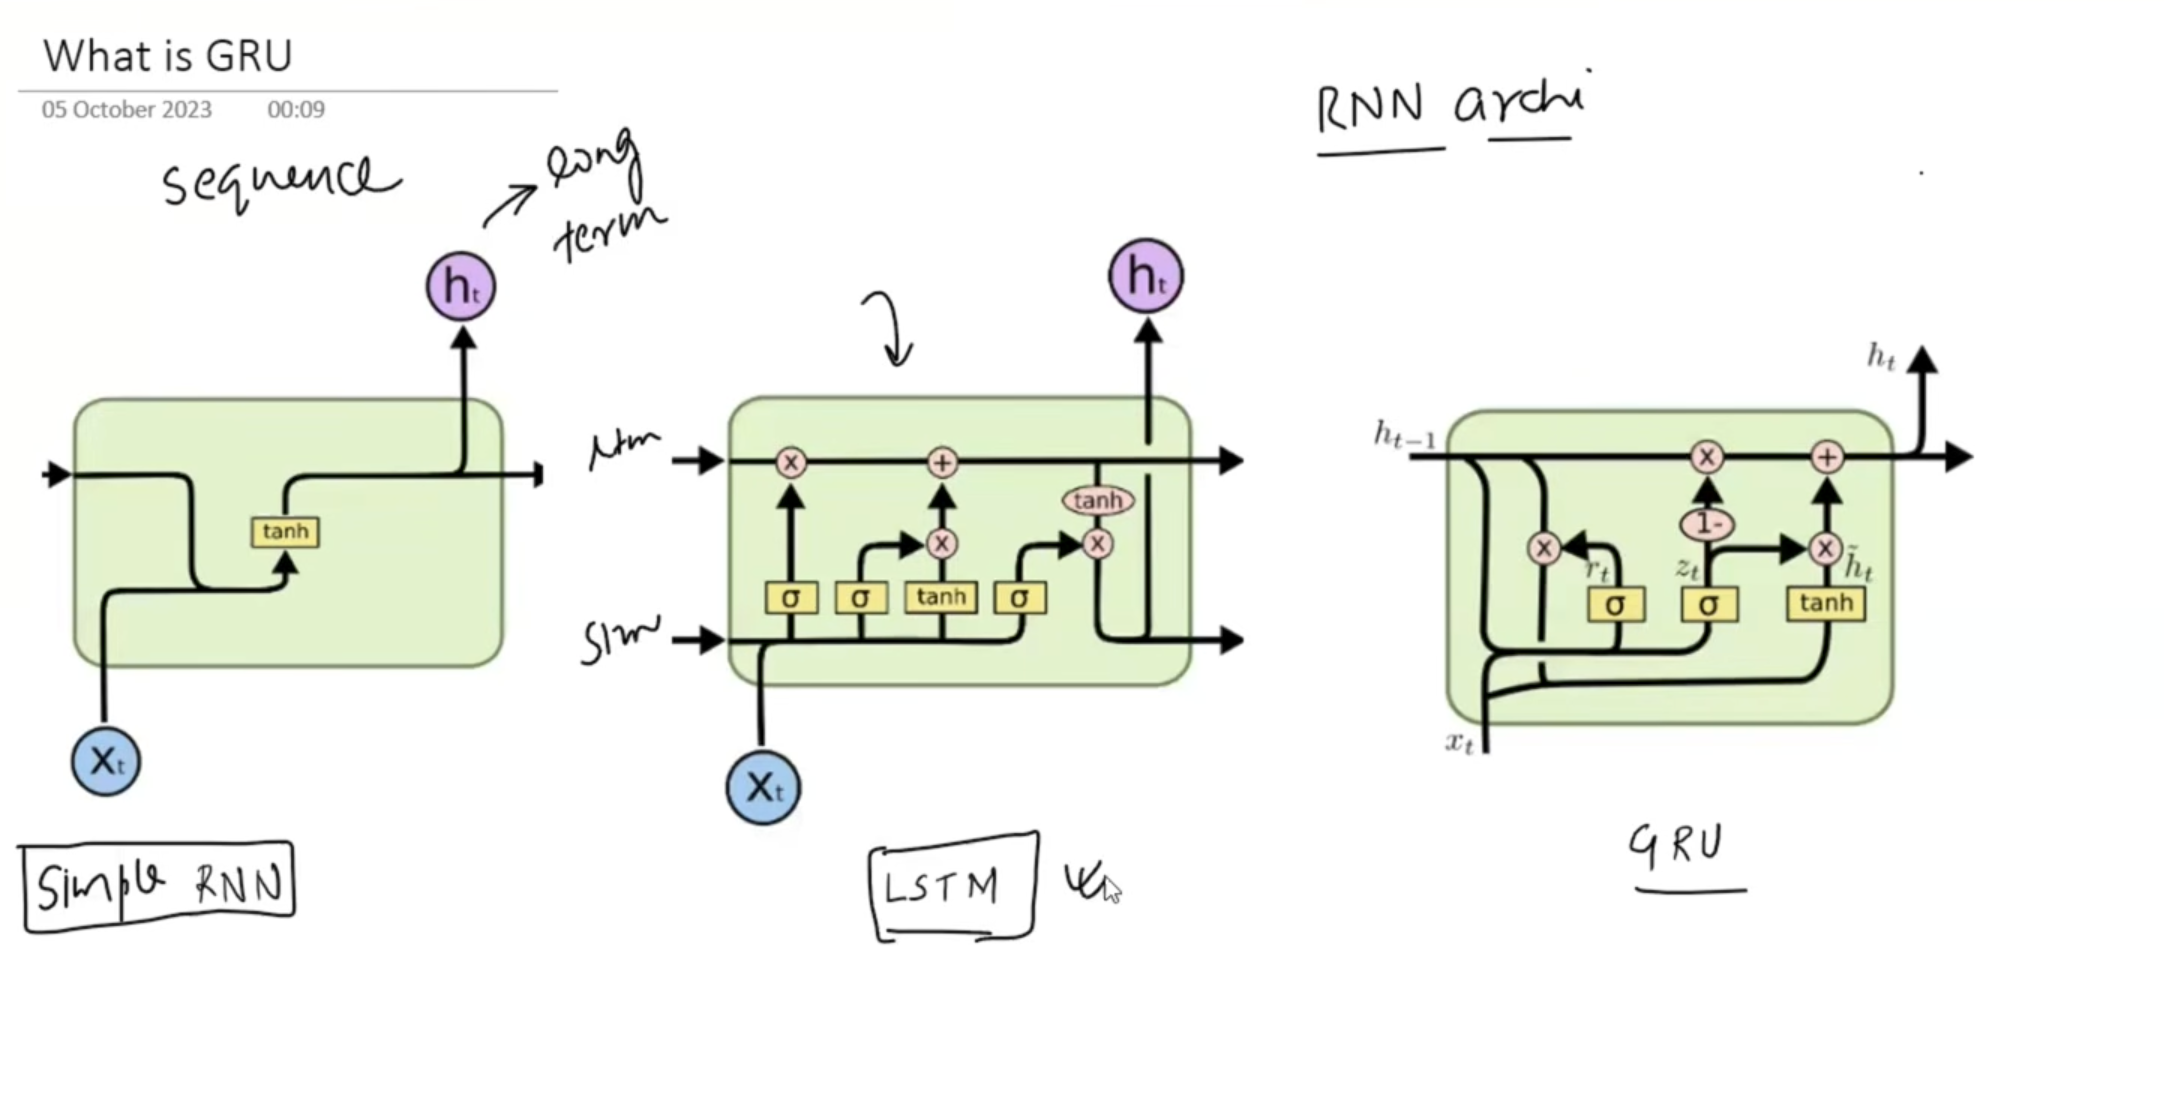

# Study Notes: Gated Recurrent Units (GRU) - Deep Learning

---

## Topic 1: Introduction to GRU & Motivation

### 1. Introduction

**What is GRU?**
GRU (Gated Recurrent Unit) is a type of Recurrent Neural Network (RNN) architecture designed to process **sequential data** - data where order matters, like sentences, time series, or audio.

**Why is it important?**
- It solves the **vanishing gradient problem** that plagues Simple RNNs
- It's simpler and faster to train than LSTM
- It performs comparably to LSTM in many tasks
- It was introduced in 2014 (more recent than LSTM from 1997)

**Real-life uses:**
- Sentiment analysis (understanding if a review is positive/negative)
- Language translation
- Text generation
- Stock price prediction
- Speech recognition

---

### 2. Detailed Explanation

#### The Problem with Simple RNNs

Simple RNNs process sequential data step by step. When the sequence becomes very long (like a long sentence), two major problems occur:

| Problem | Description |
|---------|-------------|
| **Vanishing Gradient** | Gradients become extremely small during backpropagation, making it impossible to learn long-term dependencies |
| **Exploding Gradient** | Gradients become extremely large, causing unstable training |

This means Simple RNNs **cannot retain long-term context** - they "forget" earlier parts of a sequence.

#### Why LSTM wasn't the final answer

LSTM (Long Short-Term Memory) solved these gradient problems by introducing:
- **Two separate memories**: Cell state (long-term) and Hidden state (short-term)
- **Three gates**: Forget gate, Input gate, Output gate

However, LSTM has a major drawback:
- **Complex architecture** - harder to understand and implement
- **Many parameters** - more parameters = longer training time, especially on large datasets
- **Computationally expensive**

#### Enter GRU: The Solution

GRU was introduced to address LSTM's complexity:

| Feature | LSTM | GRU |
|---------|------|-----|
| Number of gates | 3 | 2 |
| Memory units | 2 (cell + hidden) | 1 (hidden only) |
| Parameters | More | Fewer |
| Training time | Slower | Faster |
| Architecture | Complex | Simpler |

**Key Insight:** Despite being simpler, GRU often performs **comparably to or even outperforms** LSTM on certain datasets and problems.

> **Important Note:** Neither model is universally better. You should try both and see which performs better on your specific task. GRU is often the **first choice** when starting out due to its simplicity.

---

### 3. Key Points

- Simple RNNs suffer from vanishing/exploding gradient problems
- LSTM solved these but has complex architecture with 3 gates and 2 memories
- GRU (2014) provides a simpler alternative with 2 gates and 1 memory
- GRU has fewer parameters = faster training
- GRU can outperform LSTM on certain tasks
- Always empirically test both on your specific dataset

---

### 4. Common Mistakes

| Mistake | Correction |
|---------|------------|
| Assuming GRU is always better than LSTM | Performance depends on the task - test both |
| Thinking GRU and LSTM are fundamentally different | Both are RNN architectures solving the same problem with different approaches |
| Forgetting that GRU still has gates | GRU has 2 gates (Reset and Update), not zero |
| Ignoring the importance of hidden state | Hidden state IS the memory in GRU - it carries all context |

---

### 5. Interview/Exam Questions

**Q: Why was GRU introduced when LSTM already existed?**

**A:** GRU was introduced because LSTM has a complex architecture with 3 gates and 2 separate memory units (cell state and hidden state). This complexity leads to many parameters and longer training times. GRU simplifies the architecture to 2 gates and 1 memory unit, reducing parameters and training time while maintaining comparable performance.

**Q: What problem does GRU solve?**

**A:** GRU solves the vanishing and exploding gradient problems that plague Simple RNNs, allowing the network to retain long-term context in sequential data.

**Q: Does GRU always outperform LSTM?**

**A:** No. The choice depends on the specific dataset and task. Some tasks favor LSTM, others favor GRU. It's recommended to empirically test both.

**Q: Which is better for a small dataset with limited computational resources?**

**A:** GRU would be a better first choice due to its fewer parameters, faster training time, and simpler architecture.

---

### 6. Revision Notes

```
RECURRENT NEURAL NETWORKS
├── Simple RNN
│   └── ❌ Vanishing/Exploding gradients → Can't handle long sequences
├── LSTM (1997)
│   ├── ✅ Solves gradient problems
│   ├── ❌ Complex (3 gates, 2 memories)
│   └── ❌ Many parameters → Slow training
└── GRU (2014)
    ├── ✅ Solves gradient problems
    ├── ✅ Simple (2 gates, 1 memory)
    ├── ✅ Fewer parameters → Faster training
    └── ⚠️ Performance varies by task
```

**Remember:** GRU = Gated Recurrent Unit = Simpler Alternative to LSTM = Faster + Comparable Performance

---


# Topic 2: GRU Architecture - Setup and Components

---

## 1. Introduction

Before diving into the full GRU architecture, we need to understand the **building blocks** and **mathematical setup**. Think of this as learning the vocabulary and grammar before reading a complex sentence. Once you understand what each symbol represents and how the pieces fit together, the architecture becomes much easier to follow.

In this section, we'll cover:
- The **goal** of GRU at each time step
- All the **symbols** (vectors) used in the architecture
- The **neural network layers** and their activation functions
- The **element-wise operations** (multiplication, addition)

---

## 2. Detailed Explanation

### The Goal of GRU

At **every time step** (each word/input in a sequence), the GRU has a single, clear goal:

> **Given two inputs:**
> 1. Previous hidden state (hₜ₋₁) — memory from the past
> 2. Current input (xₜ) — the new word/data
>
> **Calculate:** Current hidden state (hₜ) — updated memory

This is the **fundamental objective** that everything in GRU is designed to achieve.

---

### All Symbols Explained

Here is every symbol you'll encounter in GRU architecture:

| Symbol | Name | What it means |
|--------|------|---------------|
| **hₜ₋₁** | Previous Hidden State | Memory/context from all past steps so far |
| **hₜ** | Current Hidden State | Updated memory after processing current input |
| **xₜ** | Current Input | The new data at this time step (e.g., a word) |
| **rₜ** | Reset Gate | Decides **what to forget** from past memory |
| **zₜ** | Update Gate | Decides **how much to update** vs keep from past |
| **h̃ₜ** (h with tilde) | Candidate Hidden State | Proposed new memory based mainly on current input |

#### Important Rule: All vectors (except xₜ) have the SAME dimension

If hₜ₋₁ has 4 numbers, then:
- hₜ → 4 numbers
- rₜ → 4 numbers
- zₜ → 4 numbers
- h̃ₜ → 4 numbers

**Only xₜ can have a different dimension** (e.g., 3 numbers if we represent each word with 3 features).

### What are Vectors in this Context?

A **vector** is simply a set of numbers. For example:
- A 4-dimensional vector might be: `[0.6, 0.3, 0.8, 0.1]`
- Each number represents some **aspect of the context/memory**

> **Analogy for a 4D Hidden State:**
> Imagine your hidden state has 4 numbers that represent:
> 1. **Power** in the story
> 2. **Conflict** level
> 3. **Tragedy** level  
> 4. **Revenge** level
>
> As you read a story, these numbers change to reflect the current context. The hidden state IS the memory!

---

### The Yellow Boxes: Neural Network Layers

You'll see yellow boxes in the architecture diagram with symbols like **σ (sigmoid)** or **tanh**. These are:

> **Fully Connected Neural Network Layers** (like in Artificial Neural Networks)

| Component | What it means |
|-----------|---------------|
| **Yellow box** | A small neural network layer with multiple nodes (neurons) |
| **Number of nodes** | Equal to the hidden state dimension (e.g., 4 nodes if h has 4 dimensions) |
| **σ (sigmoid)** | Sigmoid activation function — outputs values between 0 and 1 |
| **tanh** | Tanh activation function — outputs values between -1 and 1 |

#### Critical Rule #1: All three yellow boxes have the SAME number of nodes

If you choose hidden dimension = 4:
- Reset gate network → 4 nodes
- Candidate state network → 4 nodes  
- Update gate network → 4 nodes

#### Critical Rule #2: All output vectors have the SAME dimension

The dimension of rₜ, zₜ, and h̃ₜ will **always equal** the number of nodes in these layers.

---

### The Pink Operations: Element-wise Math

| Symbol | Operation | Meaning |
|--------|-----------|---------|
| **×** (inside circle) | Element-wise multiplication | Multiply two vectors position by position |
| **+** (inside circle) | Element-wise addition | Add two vectors position by position |
| **1 -** | Element-wise subtraction | Subtract each position from 1 |

#### Example: Element-wise Multiplication

If hₜ₋₁ = `[0.6, 0.8, 0.3, 0.5]` and rₜ = `[0.8, 0.2, 0.1, 0.9]`

Then hₜ₋₁ × rₜ = `[0.6×0.8, 0.8×0.2, 0.3×0.1, 0.5×0.9]`
= `[0.48, 0.16, 0.03, 0.45]`

---

### How Input Vectors (xₜ) are Created

Before GRU can process text, we must convert words into numbers using **text vectorization**.

| Technique | Description |
|-----------|-------------|
| **One-Hot Encoding** | Each unique word becomes a vector with a 1 in its position |
| **Bag of Words** | Count of word occurrences |
| **Word Embeddings** | Dense vectors capturing word meaning (e.g., Word2Vec) |

#### One-Hot Encoding Example

Vocabulary: `["Cat", "Mat", "Rat"]` (3 unique words)

| Word | Vector |
|------|--------|
| Cat | `[1, 0, 0]` |
| Mat | `[0, 1, 0]` |
| Rat | `[0, 0, 1]` |

If your sentence is `"Cat Mat Rat"`, processing at each time step:
- t=1: xₜ = `[1, 0, 0]` (Cat)
- t=2: xₜ = `[0, 1, 0]` (Mat)
- t=3: xₜ = `[0, 0, 1]` (Rat)

---

## 3. Key Points

- GRU's **goal**: Given hₜ₋₁ and xₜ, compute hₜ
- **All GRU vectors** (h, r, z, h̃) have the **same dimension** — only xₜ can differ
- **Vectors** are just sets of numbers representing context/memory
- **Yellow boxes** = Fully connected neural network layers with sigmoid or tanh
- **Pink symbols** = Element-wise operations (multiply, add, subtract)
- **Text must be converted to vectors** before feeding into GRU

---

## 4. Common Mistakes

| Mistake | Correction |
|---------|------------|
| Thinking hₜ and h̃ₜ can have different dimensions | They MUST have the same dimension |
| Forgetting that words need vectorization | GRU can't process text directly — convert to numbers first |
| Confusing element-wise multiplication with matrix multiplication | GRU uses element-wise (position-by-position) |
| Assuming xₜ has same dimension as h | xₜ can be different, but all other vectors match h's dimension |

---

## 5. Interview/Exam Questions

**Q: What is the main goal of GRU at each time step?**

**A:** To compute the current hidden state hₜ given the previous hidden state hₜ₋₁ and the current input xₜ.

**Q: What is the relationship between the dimensions of rₜ, zₜ, h̃ₜ, and hₜ?**

**A:** They all have exactly the same dimension. This dimension equals the number of hidden units in the neural network layers.

**Q: Why can't we feed text directly into GRU?**

**A:** GRU processes numbers (vectors). Text must first be converted to numeric vectors using techniques like one-hot encoding, bag of words, or word embeddings.

**Q: What's the difference between element-wise and matrix multiplication?**

**A:** Element-wise multiplication multiplies corresponding positions (position 0 with position 0, position 1 with position 1, etc.). Matrix multiplication is different and involves dot products.

---

## 6. Revision Notes

```
GRU SETUP SUMMARY

GOAL: hₜ₋₁ + xₜ → hₜ

SYMBOLS:
• hₜ₋₁ = Past memory
• xₜ   = Current input
• rₜ   = Reset gate (0 to 1)
• zₜ   = Update gate (0 to 1)
• h̃ₜ  = Candidate hidden state
• hₜ   = New memory

DIMENSIONS RULE:
┌─────────────────────────────────────┐
│  dim(hₜ₋₁) = dim(rₜ) = dim(zₜ)    │
│  = dim(h̃ₜ) = dim(hₜ)               │
│  BUT: dim(xₜ) can be DIFFERENT      │
└─────────────────────────────────────┘

LAYERS:
Yellow boxes = FC Neural Networks
σ (sigmoid) → output in [0,1] (gates)
tanh → output in [-1,1] (candidate)

OPERATIONS:
× = element-wise multiply
+ = element-wise add
1− = element-wise subtract

TEXT → VECTORS:
Use one-hot, bag-of-words, or embeddings
Each word becomes xₜ at its time step
```

---



# Topic 3: The Intuition - Hidden State as Memory (The Story Example)

---

## 1. Introduction

Before we dive into the mathematical equations and precise workings of GRU, we need to build **intuition**. What exactly is this "hidden state" we keep talking about? What do those numbers actually represent?

This topic uses a **story example** to make the abstract concept of a hidden state **concrete and understandable**. We'll see how the hidden state acts as a **living memory** that evolves as we read a sequence step by step.

---

## 2. Detailed Explanation

### What is the Hidden State?

> **The hidden state is the MEMORY of the system.**

At any point in a sequence, the hidden state contains a **summary of everything the GRU has seen so far**. It's the system's understanding of the context.

### The Story Example

Let's follow a story through a GRU to see how the hidden state changes. We'll track **4 aspects** of the story:

| Aspect | What it represents |
|--------|-------------------|
| **Power** | Presence/strength of kings and characters |
| **Conflict** | Tension, fights, battles |
| **Tragedy** | Deaths, sadness |
| **Revenge** | Desire/action for vengeance |

> **Important Note:** This is just an analogy for understanding! In reality, the numbers in a hidden state are not labeled—they are learned by the network and we can't interpret them directly. Neural networks are "black boxes." But this analogy helps explain HOW the numbers change.

---

### The Story

Here's our story, broken into sentences (time steps):

| Time | Sentence | Power | Conflict | Tragedy | Revenge |
|------|----------|-------|----------|---------|---------|
| Start | (Before any input) | 0 | 0 | 0 | 0 |
| t=1 | "There was a King Vikram, very strong and powerful" | ⬆️ 8 | 0 | 0 | 0 |
| t=2 | "There was an enemy king Kali" | ⬆️ 9 | ⬆️ 6 | 0 | 0 |
| t=3 | "Both had a war and Kali killed Vikram" | ⬇️ 7 | ⬆️ 8 | ⬆️ 9 | 0 |
| t=4 | "Vikram had a son, Vikram Junior, who grew up and became very strong" | ⬆️ 8 | ⬇️ 6 | ⬇️ 7 | ⬆️ 5 |
| t=5 | "He attacked Kali but got killed" | ⬆️ 9 | ⬆️ 8 | ⬆️ 9 | ⬆️ 7 |
| t=6 | "Vikram Junior's son, Vikram Super Junior, grew up and was strong" | ⬆️ 9 | ⬆️ 9 | ⬇️ 8 | ⬆️ 8 |
| t=7 | "He killed Kali and took revenge for his father and grandfather" | ⬇️ 8 | ⬇️ 7 | ⬇️ 6 | ⬆️ 10 |

---

### Step-by-Step Evolution of the Hidden State

#### **Start (h₀)**
`[Power: 0, Conflict: 0, Tragedy: 0, Revenge: 0]`

#### **t=1: "There was a King Vikram, very strong and powerful"**

**Input:** A king is introduced—powerful and strong

**How h₁ changes:**
- Power increases because a strong king is described
- No conflict, tragedy, or revenge yet

**h₁ ≈ `[8, 0, 0, 0]`**

---

#### **t=2: "There was an enemy king Kali"**

**Input:** Another king is introduced—an enemy

**How h₂ changes:**
- Power: increases slightly (two kings now)
- Conflict: increases (the word "enemy" introduces tension)
- Tragedy: still 0
- Revenge: still 0

**h₂ ≈ `[9, 6, 0, 0]`**

---

#### **t=3: "Both had a war and Kali killed Vikram"**

**Input:** War happened, Vikram died

**How h₃ changes:**
- Power: decreases (Vikram died, so his power is lost)
- Conflict: increases (proper war happened)
- Tragedy: increases significantly (a king died)
- Revenge: still 0 (no revenge mentioned yet)

**h₃ ≈ `[7, 8, 9, 0]`**

---

#### **t=4: "Vikram had a son, Vikram Junior, who grew up and became very strong"**

**Input:** A new king (Vikram's son) is introduced

**How h₄ changes:**
- Power: increases (a new powerful king enters)
- Conflict: decreases (growing up period—no fighting)
- Tragedy: decreases slightly (Vikram's death is further in the past)
- Revenge: increases (we anticipate revenge)

**h₄ ≈ `[8, 6, 7, 5]`**

---

#### **t=5: "He attacked Kali but got killed"**

**Input:** Vikram Junior attacks but dies

**How h₅ changes:**
- Power: increases a bit (he attacked, showing strength)
- Conflict: increases (the attack happened)
- Tragedy: increases (another death)
- Revenge: increases (he attacked for revenge)

**h₅ ≈ `[9, 8, 9, 7]`**

---

#### **t=6: "Vikram Junior's son, Vikram Super Junior, grew up and was strong"**

**Input:** Third generation king introduced

**How h₆ changes:**
- Power: stays high (another king enters)
- Conflict: increases slightly (anticipation of another fight)
- Tragedy: decreases (old deaths are further in the past)
- Revenge: increases (revenge momentum builds)

**h₆ ≈ `[9, 9, 8, 8]`**

---

#### **t=7: "He killed Kali and took revenge for his father and grandfather"**

**Input:** Final victory! Kali is killed.

**How h₇ changes:**
- Power: decreases (Kali, the enemy, is dead)
- Conflict: decreases (war is over)
- Tragedy: decreases (Kali was a villain—his death isn't tragic)
- Revenge: reaches maximum (revenge is complete)

**h₇ ≈ `[8, 7, 6, 10]`**

---

### The Big Picture: Why This Matters

This story shows how the **hidden state evolves** with each new input. The GRU's job is to:

1. **Maintain** the relevant aspects of context over time
2. **Update** the context based on new information
3. **Forget** (reduce) aspects that become less relevant
4. **Remember** aspects that remain important

> **Key Insight:** The hidden state is the GRU's **understanding of the entire story so far**, summarized as a vector of numbers.

---

### The Two-Step Transition

Now, how does GRU actually perform this transition from hₜ₋₁ to hₜ?

GRU does it in **two major steps**:

| Step | What happens |
|------|--------------|
| **Step 1** | Create a **Candidate Hidden State (h̃ₜ)** based mainly on current input |
| **Step 2** | **Balance** the old memory (hₜ₋₁) with the candidate (h̃ₜ) to create the new memory (hₜ) |

> **Analogy:** 
> - **Step 1:** Based on the new sentence you just read, you form a *draft* memory
> - **Step 2:** You combine the draft with your old memory, deciding how much of each to keep

**Why can't we just use the candidate directly?**
- The candidate is heavily influenced by the **current input only**
- The **old context** (hₜ₋₁) might still be very important for the overall story
- We need a mechanism to **balance** between old and new information
- This is where the **gates** come in!

---

### The Role of Gates in This Transition

| Gate | Role in the Story |
|------|-------------------|
| **Reset Gate (rₜ)** | Decides **which parts of the old memory to forget** before creating the candidate |
| **Update Gate (zₜ)** | Decides **how much of the old memory vs. candidate** to use for the new memory |

**Example of Reset Gate in action:**
When we read about Vikram Junior growing up (t=4), the reset gate says:
- "Keep the power aspect (it's still relevant)"
- "Lower the conflict aspect (no fighting right now)"
- "Lower the tragedy aspect (Vikram's death is old news)"
- "Increase the revenge aspect (we sense revenge coming)"

**Example of Update Gate in action:**
When we read the final sentence about revenge (t=7):
- Update gate says: "This current input is VERY important—use a lot of it!"
- The new memory becomes heavily influenced by this current input

---

## 3. Key Points

- The **hidden state is memory**—it summarizes everything seen so far
- Each number in the hidden state vector represents **some aspect** of the context
- The hidden state **evolves** with each new input
- GRU transitions from hₜ₋₁ to hₜ in **two steps**:
  1. Create candidate hidden state (h̃ₜ) from current input
  2. Balance old memory and candidate to create new memory
- **Reset gate** decides what to forget from old memory
- **Update gate** decides how much old vs. new to keep

---

## 4. Common Mistakes

| Mistake | Correction |
|---------|------------|
| Thinking the numbers in hidden state have human-readable labels | They don't! The network learns abstract representations—this is just an analogy |
| Believing the story aspects are fixed | The network could learn any number of "aspects"—we don't know what they are |
| Confusing "forgetting" with "erasing to zero" | Gates reduce values but don't necessarily eliminate them completely |
| Thinking the candidate state is always better than old memory | Sometimes old memory is more important—that's why we need the update gate |

---

## 5. Interview/Exam Questions

**Q: What does the hidden state represent in a GRU?**

**A:** The hidden state represents the memory/context of everything the GRU has processed so far. It's a vector that summarizes the sequence up to the current time step.

**Q: Why does GRU need two steps to update the hidden state?**

**A:** Because GRU needs to balance information from the past (hₜ₋₁) with new information from the current input (xₜ). Creating a candidate state first allows the network to propose a new memory, then the update gate decides how much of the old memory to keep versus the candidate.

**Q: What would happen if we directly used the candidate as the new hidden state?**

**A:** The new memory would be too heavily influenced by the current input, potentially losing important long-term context that's still relevant to the overall sequence.

**Q: Why is the hidden state considered a "black box"?**

**A:** Because we can't directly interpret what each number in the vector represents. The network learns abstract representations during training that don't correspond to human-understandable concepts.

---

## 6. Revision Notes

```
HIDDEN STATE = MEMORY

STORY ASPECTS ANALOGY:
┌────────────────────────────────────────┐
│  h = [Power, Conflict, Tragedy, Revenge] │
│                                        │
│  Each number changes as story progresses │
└────────────────────────────────────────┘

TRANSITION: hₜ₋₁ → hₜ
┌─────────────────────────────────────────┐
│  STEP 1: hₜ₋₁ + xₜ → h̃ₜ (candidate)  │
│          (heavily influenced by xₜ)    │
│                                         │
│  STEP 2: Balance hₜ₋₁ and h̃ₜ → hₜ    │
│          (decide how much of each)     │
└─────────────────────────────────────────┘

ROLE OF GATES:
┌─────────────────────────────────────────┐
│  Reset Gate (rₜ): "What to forget?"    │
│  Update Gate (zₜ): "How much to update?" │
└─────────────────────────────────────────┘

WHY NOT JUST USE CANDIDATE?
→ Old context might still be important!
→ Need balance between past and present
```

---



# Topic 4: GRU Architecture - The Four Steps (Mathematical Details)

---

## 1. Introduction

Now we finally dive into the **complete GRU architecture**. We've built the foundation:
- We know the symbols and what they mean (Topic 2)
- We understand the hidden state as memory (Topic 3)

Now we'll see how GRU actually **computes** everything. The entire process happens in **4 steps**, with the two gates playing starring roles.

> **Big Picture:** GRU takes hₜ₋₁ and xₜ, and through 4 clear steps, produces hₜ. The process involves creating two gates (reset and update), generating a candidate memory, and finally balancing everything.

---

## 2. Detailed Explanation

### The 4-Step Process Overview

| Step | What's Calculated | What It Does |
|------|-------------------|--------------|
| **Step 1** | **Reset Gate (rₜ)** | Calculated from hₜ₋₁ and xₜ. Decides what to forget from past memory |
| **Step 2** | **Candidate Hidden State (h̃ₜ)** | Uses reset gate to modify past memory, then combines with xₜ to propose new memory |
| **Step 3** | **Update Gate (zₜ)** | Calculated from hₜ₋₁ and xₜ. Decides how to balance old vs. new memory |
| **Step 4** | **Current Hidden State (hₜ)** | Combines old memory and candidate using the update gate |

> **Flow Diagram Overview:**
> ```
> hₜ₋₁ + xₜ → Step 1: rₜ (Reset Gate)
>                    ↓
> hₜ₋₁ + rₜ → Step 2: h̃ₜ (Candidate Hidden State)
>                    ↓
> hₜ₋₁ + xₜ → Step 3: zₜ (Update Gate)
>                    ↓
> hₜ₋₁ + h̃ₜ + zₜ → Step 4: hₜ (Current Hidden State)
> ```

---

### Step 1: Calculate the Reset Gate (rₜ)

#### The Intuition

The reset gate answers: **"Based on the current input, which parts of my past memory should I forget?"**

- **rₜ values close to 1:** "Keep this part of the memory"
- **rₜ values close to 0:** "Forget/reset this part of the memory"

#### The Formula

> **rₜ = σ(Wᵣ · [hₜ₋₁, xₜ] + bᵣ)**

Breaking this down:

| Component | Meaning |
|-----------|---------|
| **hₜ₋₁** | Previous hidden state (past memory) |
| **xₜ** | Current input |
| **[hₜ₋₁, xₜ]** | Concatenate (join together) both vectors |
| **Wᵣ** | Weight matrix for reset gate (learned during training) |
| **bᵣ** | Bias for reset gate (learned during training) |
| **σ** | Sigmoid activation function → output between 0 and 1 |

#### Visual Representation

```
         hₜ₋₁ ─────────┐
                       │
                       ▼
              ┌────────────────┐
         xₜ ──│  Neural Net +  │── rₜ (all values between 0-1)
              │    Sigmoid     │
              └────────────────┘
```

#### Example with Numbers

Suppose hₜ₋₁ = `[0.6, 0.8, 0.7, 0.3]` and xₜ = `[0.4, 0.2, 0.9]`

After passing through the neural network with sigmoid, we get:
**rₜ ≈ `[0.8, 0.2, 0.1, 0.9]`**

**What this means:**
- Dimension 1 (e.g., Power): Keep 80% of the old memory (0.8) → "Power still relevant"
- Dimension 2 (e.g., Conflict): Keep only 20% of the old memory (0.2) → "Not much conflict now"
- Dimension 3 (e.g., Tragedy): Keep only 10% (0.1) → "Past tragedy isn't important anymore"
- Dimension 4 (e.g., Revenge): Keep 90% (0.9) → "Revenge is becoming important"

---

### Step 2: Calculate the Candidate Hidden State (h̃ₜ)

#### The Intuition

The candidate hidden state is a **proposed new memory** based heavily on the current input. But first, we use the reset gate to **modify the past memory** before adding the current input.

> **Think of it like:**
> 1. First, forget some parts of your old memory (using reset gate)
> 2. Then, add information from the current input
> 3. The result is the candidate memory

#### The Formula

> **h̃ₜ = tanh(Wₕ · [(rₜ × hₜ₋₁), xₜ] + bₕ)**

Breaking this down:

| Component | Meaning |
|-----------|---------|
| **rₜ × hₜ₋₁** | Element-wise multiplication of reset gate and old memory → "Modified past memory" |
| **[(rₜ × hₜ₋₁), xₜ]** | Concatenate the modified memory with current input |
| **Wₕ** | Weight matrix for candidate state (learned) |
| **bₕ** | Bias for candidate state (learned) |
| **tanh** | Tanh activation → output between -1 and 1 |

#### Visual Representation

```
hₜ₋₁ ──┐    rₜ ─────────┐
       │                │
       └─────×──────────┤
              │         │
              ▼         │
         Modified   ────┤
         Memory         │
                        ▼
                ┌────────────────┐
          xₜ ───│  Neural Net +  │── h̃ₜ (candidate)
                │     tanh       │
                └────────────────┘
```

#### Step-by-Step Calculation

**1. Modify the past memory:**
- rₜ × hₜ₋₁ (element-wise multiplication)

If hₜ₋₁ = `[0.6, 0.8, 0.7, 0.3]` and rₜ = `[0.8, 0.2, 0.1, 0.9]`:

```
rₜ × hₜ₋₁ = [0.6×0.8, 0.8×0.2, 0.7×0.1, 0.3×0.9]
           = [0.48, 0.16, 0.07, 0.27]
```

**2. Concatenate with xₜ:**

If xₜ = `[0.4, 0.2, 0.9]`:
```
[(rₜ × hₜ₋₁), xₜ] = [0.48, 0.16, 0.07, 0.27, 0.4, 0.2, 0.9]
```

**3. Pass through neural network with tanh:**

Suppose after the neural network we get:
**h̃ₜ ≈ `[0.7, 0.3, 0.1, 0.4]`**

**What this means:**
- This is the **proposed memory** based on the current input
- It has "forgotten" some parts that were less relevant (thanks to reset gate)
- It reflects the new information from xₜ

---

### Step 3: Calculate the Update Gate (zₜ)

#### The Intuition

The update gate answers: **"How much of my old memory should I keep vs. how much of the candidate should I use?"**

- **zₜ close to 0:** "Keep mostly old memory" → Story hasn't changed much
- **zₜ close to 1:** "Use mostly candidate" → Story has significantly changed

#### The Formula

> **zₜ = σ(W_z · [hₜ₋₁, xₜ] + b_z)**

Breaking this down:

| Component | Meaning |
|-----------|---------|
| **hₜ₋₁** | Previous hidden state |
| **xₜ** | Current input |
| **[hₜ₋₁, xₜ]** | Concatenate both vectors |
| **W_z** | Weight matrix for update gate (learned) |
| **b_z** | Bias for update gate (learned) |
| **σ** | Sigmoid activation → output between 0 and 1 |

#### Visual Representation

```
         hₜ₋₁ ─────────┐
                       │
                       ▼
              ┌────────────────┐
         xₜ ──│  Neural Net +  │── zₜ (all values between 0-1)
              │    Sigmoid     │
              └────────────────┘
```

#### Example with Numbers

Suppose after the neural network with sigmoid:
**zₜ ≈ `[0.7, 0.5, 0.8, 0.4]`**

**What this means:**
- Dimension 1: Use 70% candidate, 30% old → moderately update
- Dimension 2: Use 50% candidate, 50% old → balanced
- Dimension 3: Use 80% candidate, 20% old → heavily update
- Dimension 4: Use 40% candidate, 60% old → mostly keep old

---

### Step 4: Calculate the Current Hidden State (hₜ)

#### The Intuition

This is the **final balancing act**. We combine the old memory (hₜ₋₁) and the candidate memory (h̃ₜ) using the update gate (zₜ) to create the new memory.

> **Formula Explanation:**
> - **zₜ** controls how much we keep from the candidate
> - **(1 - zₜ)** controls how much we keep from the old memory
> - When zₜ is high → we trust the candidate more
> - When zₜ is low → we trust the old memory more

#### The Formula

> **hₜ = (1 - zₜ) × hₜ₋₁ + zₜ × h̃ₜ**

Breaking this down:

| Component | Meaning |
|-----------|---------|
| **(1 - zₜ)** | Element-wise: 1 minus each value in zₜ |
| **(1 - zₜ) × hₜ₋₁** | How much to keep from old memory |
| **zₜ × h̃ₜ** | How much to take from candidate memory |
| **+** | Element-wise addition → final new memory |

#### Visual Representation

```
              ┌─────────────────┐
              │   1 - zₜ        │
              └────────┬────────┘
                       │
            hₜ₋₁ ──────×──────────┐
                                  │
                                  ▼
                                 [+] ── hₜ
                                  ▲
                                  │
            h̃ₜ ───────×──────────┘
                       │
              ┌────────┴────────┐
              │     zₜ          │
              └─────────────────┘
```

#### Step-by-Step Calculation

**1. Calculate (1 - zₜ):**

If zₜ = `[0.7, 0.5, 0.8, 0.4]`:
```
1 - zₜ = [0.3, 0.5, 0.2, 0.6]
```

**2. Keep old memory:**
```
(1 - zₜ) × hₜ₋₁ = [0.3×0.6, 0.5×0.8, 0.2×0.7, 0.6×0.3]
                 = [0.18, 0.40, 0.14, 0.18]
```

**3. Take candidate memory:**
```
zₜ × h̃ₜ = [0.7×0.7, 0.5×0.3, 0.8×0.1, 0.4×0.4]
         = [0.49, 0.15, 0.08, 0.16]
```

**4. Add them together:**
```
hₜ = [0.18+0.49, 0.40+0.15, 0.14+0.08, 0.18+0.16]
   = [0.67, 0.55, 0.22, 0.34]
```

**Final hₜ ≈ `[0.67, 0.55, 0.22, 0.34]`**

**What this means:**
- This is the **new memory** after processing the current input
- It's a balanced mix of the old memory and the candidate
- It will be passed to the next time step as hₜ₋₁

---

### Complete Flow Summary

```
INPUT: hₜ₋₁ (past memory) + xₜ (current input)

STEP 1 (Reset Gate):    rₜ = σ(Wᵣ·[hₜ₋₁, xₜ] + bᵣ)
                                      ↓
STEP 2 (Candidate):    h̃ₜ = tanh(Wₕ·[(rₜ×hₜ₋₁), xₜ] + bₕ)
                                      ↓
STEP 3 (Update Gate):   zₜ = σ(W_z·[hₜ₋₁, xₜ] + b_z)
                                      ↓
STEP 4 (Final State):   hₜ = (1-zₜ)×hₜ₋₁ + zₜ×h̃ₜ

OUTPUT: hₜ (new memory)
```

---

## 3. Key Points

- GRU works in **4 clear steps**: reset gate → candidate → update gate → final state
- **Reset gate (rₜ):** Controls what to forget from past memory (values 0-1)
- **Candidate (h̃ₜ):** Proposes new memory based on modified past + current input
- **Update gate (zₜ):** Controls how to balance old vs. candidate memory (values 0-1)
- **Final hidden state (hₜ):** Combines old memory and candidate using the update gate
- The **same dimension** is maintained throughout all calculations

---

## 4. Common Mistakes

| Mistake | Correction |
|---------|------------|
| Confusing which gate comes first | Reset gate comes first, then update gate |
| Forgetting the reset gate modifies memory BEFORE candidate calculation | hₜ₋₁ is multiplied by rₜ first, THEN combined with xₜ |
| Thinking h̃ₜ is the final output | h̃ₜ is just a candidate—the update gate decides how much to use |
| Mixing up the order of operations in hₜ formula | It's (1-zₜ)×hₜ₋₁ + zₜ×h̃ₜ, NOT vice versa |
| Assuming zₜ and rₜ are just numbers | They are VECTORS with the same dimension as h |

---

## 5. Interview/Exam Questions

**Q: What are the 4 steps in a GRU forward pass?**

**A:**
1. Calculate reset gate: rₜ = σ(Wᵣ·[hₜ₋₁, xₜ] + bᵣ)
2. Calculate candidate state: h̃ₜ = tanh(Wₕ·[(rₜ×hₜ₋₁), xₜ] + bₕ)
3. Calculate update gate: zₜ = σ(W_z·[hₜ₋₁, xₜ] + b_z)
4. Calculate final state: hₜ = (1-zₜ)×hₜ₋₁ + zₜ×h̃ₜ

**Q: Why do we multiply hₜ₋₁ by rₜ before creating the candidate?**

**A:** The reset gate controls what parts of the past memory to forget before incorporating new information. This allows the GRU to discard irrelevant context when forming the candidate memory.

**Q: What's the difference between reset gate and update gate?**

**A:** The reset gate (rₜ) controls what to forget from past memory when creating the candidate. The update gate (zₜ) controls how much of the old memory to keep vs. how much of the candidate to use in the final hidden state.

**Q: What happens if the update gate zₜ is all zeros?**

**A:** If zₜ = [0,0,0,...], then hₜ = hₜ₋₁. The GRU completely ignores the current input and keeps the old memory unchanged.

**Q: What happens if the update gate zₜ is all ones?**

**A:** If zₜ = [1,1,1,...], then hₜ = h̃ₜ. The GRU completely ignores the old memory and uses only the candidate state.

---

## 6. Revision Notes

```
GRU 4-STEP CHEAT SHEET

STEP 1: rₜ = σ(Wᵣ·[hₜ₋₁, xₜ] + bᵣ)
    → Reset gate: What to forget? (0-1)

STEP 2: h̃ₜ = tanh(Wₕ·[(rₜ×hₜ₋₁), xₜ] + bₕ)
    → Candidate: Propose new memory (-1 to 1)

STEP 3: zₜ = σ(W_z·[hₜ₋₁, xₜ] + b_z)
    → Update gate: How much to update? (0-1)

STEP 4: hₜ = (1-zₜ)×hₜ₋₁ + zₜ×h̃ₜ
    → Final state: Balance old + candidate

VISUAL FLOW:
┌──────────────────────────────────────────────────────┐
│  hₜ₋₁ ──┬─────→ [Step 1] ─→ rₜ ───────────┐     │
│         │                    ↓              │     │
│         │         rₜ × hₜ₋₁ ─→ [Step 2] ─→ h̃ₜ ┐ │
│         │                    ↓              ↓ │ │
│         └─────→ [Step 3] ─→ zₜ ───→ [Step 4] ←┘ │
│                              ↓              ↓     │
│  xₜ ──────────────────────────────────────→ hₜ     │
└──────────────────────────────────────────────────────┘
```

---



# Topic 5: Complete Architecture Walkthrough & Comparison with LSTM

---

## 1. Introduction

Now that we understand all four steps individually, let's put everything together into one **complete picture**. We'll walk through the entire GRU architecture from start to finish, showing how all the components connect.

Then, we'll compare GRU with LSTM side-by-side to understand:
- **Why** GRU is simpler
- **Where** each performs better
- **When** to choose one over the other

---

## 2. Detailed Explanation

### Complete GRU Architecture Diagram (Text Representation)

```
                    ┌─────────────────────────────────────────────────────┐
                    │                                                   │
                    │            GRU CELL (Time Step t)                │
                    │                                                   │
                    ▼                                                   │
              ┌──────────┐                                              │
              │   xₜ     │ (Current Input)                             │
              └────┬─────┘                                              │
                   │                                                    │
                   ▼                                                    │
    ┌─────────────────────────────────────────────────────────────────┐│
    │                                                                  ││
    │  ┌─────────────────────────────────────────────────────────┐    ││
    │  │                                                         │    ││
    │  │  STEP 1: RESET GATE (rₜ)                               │    ││
    │  │                                                         │    ││
    │  │  hₜ₋₁ ─────┐                                          │    ││
    │  │            │                                          │    ││
    │  │            ▼                                          │    ││
    │  │         [Concatenate] ──→ Neural Net + Sigmoid ──→ rₜ│    ││
    │  │            ▲                                          │    ││
    │  │            │                                          │    ││
    │  │  xₜ ───────┘                                          │    ││
    │  └─────────────────────────────────────────────────────────┘    ││
    │                           │                                      ││
    │                           ▼                                      ││
    │  ┌─────────────────────────────────────────────────────────┐    ││
    │  │                                                         │    ││
    │  │  STEP 2: CANDIDATE HIDDEN STATE (h̃ₜ)                  │    ││
    │  │                                                         │    ││
    │  │  hₜ₋₁ ────×──────────┐                                │    ││
    │  │          ▲            │                                │    ││
    │  │          │            ▼                                │    ││
    │  │  rₜ ─────┘     [Concatenate] ──→ Neural Net + tanh ─→ h̃ₜ│    ││
    │  │                               ▲                        │    ││
    │  │                               │                        │    ││
    │  │  xₜ ──────────────────────────┘                        │    ││
    │  └─────────────────────────────────────────────────────────┘    ││
    │                           │                                      ││
    │                           ▼                                      ││
    │  ┌─────────────────────────────────────────────────────────┐    ││
    │  │                                                         │    ││
    │  │  STEP 3: UPDATE GATE (zₜ)                              │    ││
    │  │                                                         │    ││
    │  │  hₜ₋₁ ─────┐                                          │    ││
    │  │            │                                          │    ││
    │  │            ▼                                          │    ││
    │  │         [Concatenate] ──→ Neural Net + Sigmoid ──→ zₜ│    ││
    │  │            ▲                                          │    ││
    │  │            │                                          │    ││
    │  │  xₜ ───────┘                                          │    ││
    │  └─────────────────────────────────────────────────────────┘    ││
    │                           │                                      ││
    │                           ▼                                      ││
    │  ┌─────────────────────────────────────────────────────────┐    ││
    │  │                                                         │    ││
    │  │  STEP 4: FINAL HIDDEN STATE (hₜ)                       │    ││
    │  │                                                         │    ││
    │  │  hₜ₋₁ ────×────(1-zₜ)─┐                               │    ││
    │  │                         │                               │    ││
    │  │                         ▼                               │    ││
    │  │                      [ADD] ──────────────────────→ hₜ   │    ││
    │  │                         ▲                               │    ││
    │  │                         │                               │    ││
    │  │  h̃ₜ ─────×────────zₜ───┘                               │    ││
    │  │                                                         │    ││
    │  └─────────────────────────────────────────────────────────┘    ││
    │                                                                  ││
    └─────────────────────────────────────────────────────────────────┘│
                                                                        │
                                                                        ▼
                                                             ┌──────────────┐
                                                             │   hₜ        │
                                                             │  (Output     │
                                                             │   to next    │
                                                             │   time step) │
                                                             └──────────────┘
```

---

### Step-by-Step Data Flow

Let's trace the flow of data through the GRU cell:

#### **Inputs Entering the Cell:**
1. **hₜ₋₁** (Previous Hidden State) - enters from the top-left
2. **xₜ** (Current Input) - enters from the bottom

#### **Three Parallel Paths:**

| Path | Destination | What Happens |
|------|-------------|--------------|
| **Path 1** | Reset Gate | hₜ₋₁ and xₜ are concatenated → passed through neural network with sigmoid → produces rₜ |
| **Path 2** | Candidate State | hₜ₋₁ is multiplied by rₜ (element-wise) → concatenated with xₜ → passed through neural network with tanh → produces h̃ₜ |
| **Path 3** | Update Gate | hₜ₋₁ and xₜ are concatenated → passed through neural network with sigmoid → produces zₜ |

#### **Final Combination:**
- hₜ₋₁ is multiplied by (1 - zₜ) → keeps part of old memory
- h̃ₜ is multiplied by zₜ → takes part of candidate
- Both are added together → produces **hₜ** (output)

---

### The Complete Mathematical Summary

```
At each time step t:

1. Reset Gate:    rₜ = σ(Wᵣ·[hₜ₋₁, xₜ] + bᵣ)

2. Candidate:     h̃ₜ = tanh(Wₕ·[(rₜ⊙hₜ₋₁), xₜ] + bₕ)

3. Update Gate:   zₜ = σ(W_z·[hₜ₋₁, xₜ] + b_z)

4. Final State:   hₜ = (1-zₜ)⊙hₜ₋₁ + zₜ⊙h̃ₜ

Where:
- σ = sigmoid function
- ⊙ = element-wise multiplication
- W = weight matrices (learned)
- b = biases (learned)
- [a, b] = concatenation of vectors a and b
```

---

### LSTM vs. GRU: A Detailed Comparison

#### 1. Number of Gates

| Architecture | Gates | Names |
|--------------|-------|-------|
| **LSTM** | 3 | Forget Gate, Input Gate, Output Gate |
| **GRU** | 2 | Reset Gate, Update Gate |

> **Why this matters:** Fewer gates = simpler architecture = faster computation.

#### 2. Memory Units

| Architecture | Memory Units |
|--------------|--------------|
| **LSTM** | 2 (Cell State + Hidden State) |
| **GRU** | 1 (Hidden State only) |

> **Why this matters:** GRU doesn't maintain separate long-term and short-term memory—one state handles both.

#### 3. Parameter Count

**LSTM Parameter Formula:**
> **4 × (hidden_size × (input_size + hidden_size + 1))**

**GRU Parameter Formula:**
> **3 × (hidden_size × (input_size + hidden_size + 1))**

| Architecture | Total Parameters (for example with input_size=100, hidden_size=50) |
|--------------|---------------------------------------------------------------------|
| **LSTM** | 4 × (50 × (100 + 50 + 1)) = 4 × 50 × 151 = **30,200** |
| **GRU** | 3 × (50 × (100 + 50 + 1)) = 3 × 50 × 151 = **22,650** |

> **GRU has ~25% fewer parameters** in this example!

#### 4. Computational Complexity

| Architecture | Complexity | Training Speed |
|--------------|------------|----------------|
| **LSTM** | Higher (more operations, more parameters) | Slower |
| **GRU** | Lower (fewer operations, fewer parameters) | Faster |

#### 5. Performance Comparison

| Scenario | Likely Better Choice |
|----------|---------------------|
| **Complex tasks with large datasets** | LSTM may perform slightly better |
| **Smaller datasets** | GRU performs well and trains faster |
| **Limited computational resources** | GRU is more efficient |
| **When starting out** | GRU is a good first choice |
| **When LSTM doesn't improve performance** | GRU is a good fallback |

> **Important:** Performance depends on the specific task and dataset. Neither is universally better. **Empirical testing is key!**

---

### Summary Comparison Table

| Feature | LSTM | GRU |
|---------|------|-----|
| **Year Introduced** | 1997 | 2014 |
| **Number of Gates** | 3 | 2 |
| **Memory Units** | 2 (Cell + Hidden) | 1 (Hidden) |
| **Parameter Count** | Higher | Lower |
| **Training Speed** | Slower | Faster |
| **Architecture Complexity** | Complex | Simpler |
| **Performance on Complex Tasks** | Often better | Good |
| **Performance on Limited Data** | May overfit | Often better |
| **Ease of Understanding** | Harder | Easier |
| **Computational Resources** | More demanding | Less demanding |

---

### When to Choose GRU vs. LSTM

```
┌─────────────────────────────────────────────────────────────────┐
│                    DECISION FLOWCHART                          │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  START: Choose an RNN architecture                             │
│         │                                                      │
│         ▼                                                      │
│  Is the dataset small OR computational resources limited?     │
│         │                                                      │
│    ┌────┴────┐                                                │
│    │         │                                                │
│   YES       NO                                                │
│    │         │                                                │
│    ▼         ▼                                                │
│  START    Is the task very complex requiring                 │
│  WITH       long-term dependencies?                          │
│  GRU          │                                               │
│               │                                               │
│         ┌─────┴─────┐                                        │
│         │           │                                        │
│        YES         NO                                        │
│         │           │                                        │
│         ▼           ▼                                        │
│    TRY BOTH    START WITH                                     │
│    LSTM &      GRU (simpler)                                  │
│    GRU         │                                              │
│         │      │                                              │
│         ▼      ▼                                              │
│    Empirical Testing → Choose the one with better            │
│                        performance on your task              │
└─────────────────────────────────────────────────────────────────┘
```

**Practical Advice:**
1. **Start with GRU** - simpler, faster, and often performs well enough
2. **If GRU underperforms, try LSTM** - it may capture more complex patterns
3. **Always test both empirically** - performance depends on your specific data
4. **Consider your constraints** - time, computational resources, dataset size

---

## 3. Key Points

- GRU has **4 clear steps** in its forward pass
- The **reset gate (rₜ)** modifies past memory before creating the candidate
- The **candidate (h̃ₜ)** proposes new memory based on current input
- The **update gate (zₜ)** balances old and new memory
- GRU is **simpler than LSTM** - fewer gates, fewer parameters, faster training
- GRU can **outperform LSTM** on some tasks (especially with limited data)
- **Empirical testing** is essential - try both!

---

## 4. Common Mistakes

| Mistake | Correction |
|---------|------------|
| Thinking GRU has no gates | GRU has 2 gates: Reset and Update |
| Assuming GRU always uses less memory | GRU uses 1 state vs. LSTM's 2, but both process sequences step by step |
| Believing GRU is always worse than LSTM | GRU can outperform LSTM on certain tasks |
| Forgetting to concatenate before passing to neural network layers | Both gates and candidate require concatenation of inputs |
| Confusing which gate is for forgetting vs. updating | Reset gate = forgetting/modifying; Update gate = balancing old vs. new |

---

## 5. Interview/Exam Questions

**Q: What are the main differences between LSTM and GRU?**

**A:**
1. **Gates:** LSTM has 3 (Forget, Input, Output) vs. GRU has 2 (Reset, Update)
2. **Memory:** LSTM has 2 states (Cell + Hidden) vs. GRU has 1 (Hidden)
3. **Parameters:** LSTM has more parameters (4×hidden×(input+hidden+1)) vs. GRU has fewer (3×hidden×(input+hidden+1))
4. **Complexity:** LSTM is more complex, GRU is simpler and trains faster
5. **Performance:** LSTM may perform better on very complex tasks; GRU performs well on many tasks, especially with limited data

**Q: When would you choose GRU over LSTM?**

**A:** You would choose GRU when:
- You have limited computational resources
- Your dataset is small
- You want faster training times
- The task doesn't require the extra complexity of LSTM
- As a first choice to test performance

**Q: Can GRU outperform LSTM?**

**A:** Yes! GRU has been shown to outperform LSTM on certain tasks and datasets, especially when data is limited or the task is less complex. Performance is data-dependent, so empirical testing is recommended.

**Q: Why does GRU train faster than LSTM?**

**A:** GRU has fewer gates (2 vs 3) and fewer parameters (3×hidden×(input+hidden+1) vs 4×hidden×(input+hidden+1)). This means fewer operations per forward/backward pass, resulting in faster training.

**Q: Is GRU always better than LSTM?**

**A:** No. The choice depends on the specific task and dataset. While GRU is simpler and faster, LSTM may capture more complex patterns. Always test both empirically.

---

## 6. Revision Notes

```
COMPLETE GRU SUMMARY

INPUTS: hₜ₋₁ (past memory) + xₜ (current input)

STEP 1: rₜ = σ(Wᵣ·[hₜ₋₁, xₜ] + bᵣ)
        → Reset gate: What to forget? (0-1)

STEP 2: h̃ₜ = tanh(Wₕ·[(rₜ⊙hₜ₋₁), xₜ] + bₕ)
        → Candidate: Proposed new memory

STEP 3: zₜ = σ(W_z·[hₜ₋₁, xₜ] + b_z)
        → Update gate: How much to update? (0-1)

STEP 4: hₜ = (1-zₜ)⊙hₜ₋₁ + zₜ⊙h̃ₜ
        → Final new memory

OUTPUT: hₜ (to next time step)

GRU vs LSTM:
┌────────────────┬──────────────────┬──────────────────┐
│    Feature     │      LSTM        │      GRU         │
├────────────────┼──────────────────┼──────────────────┤
│ Gates          │ 3 (F, I, O)     │ 2 (R, U)         │
│ Memory States  │ 2 (Cell+Hidden)  │ 1 (Hidden)       │
│ Parameters     │ Higher           │ Lower (~25% less)│
│ Training Speed │ Slower           │ Faster           │
│ Complexity     │ Complex          │ Simpler          │
└────────────────┴──────────────────┴──────────────────┘

DECISION RULE:
1. Start with GRU (simpler, faster)
2. If needed, try LSTM (more complex)
3. Choose based on empirical performance!
```

---



# Topic 6: Interview Questions, Common Mistakes & Final Revision

---

## 1. Introduction

This final topic consolidates everything we've learned about GRU. We'll cover:
- **Comprehensive interview questions** with detailed answers
- **Common mistakes** beginners make and how to avoid them
- **Final revision notes** for quick recall

---

## 2. Comprehensive Interview Questions & Answers

### Beginner Level Questions

**Q1: What is GRU and what does it stand for?**

**A:** GRU stands for **Gated Recurrent Unit**. It's a type of Recurrent Neural Network (RNN) architecture designed to process sequential data while solving the vanishing gradient problem. It was introduced in 2014 as a simpler alternative to LSTM.

---

**Q2: What problem does GRU solve?**

**A:** GRU solves the **vanishing and exploding gradient problems** that occur in Simple RNNs when processing long sequences. This allows the network to retain long-term context and learn dependencies across many time steps.

---

**Q3: How many gates does GRU have? What are they called?**

**A:** GRU has **2 gates:**
1. **Reset Gate (rₜ)** - Controls what to forget from past memory
2. **Update Gate (zₜ)** - Controls how to balance old and new memory

---

**Q4: What is the hidden state in GRU?**

**A:** The hidden state (hₜ) is the **memory of the system**. It's a vector that summarizes everything the GRU has processed so far. Unlike LSTM, GRU uses only one hidden state (no separate cell state).

---

### Intermediate Level Questions

**Q5: Explain the four steps of GRU's forward pass.**

**A:**

| Step | Formula | Purpose |
|------|---------|---------|
| 1 | rₜ = σ(Wᵣ·[hₜ₋₁, xₜ] + bᵣ) | Calculate reset gate (what to forget) |
| 2 | h̃ₜ = tanh(Wₕ·[(rₜ⊙hₜ₋₁), xₜ] + bₕ) | Create candidate hidden state |
| 3 | zₜ = σ(W_z·[hₜ₋₁, xₜ] + b_z) | Calculate update gate (how much to update) |
| 4 | hₜ = (1-zₜ)⊙hₜ₋₁ + zₜ⊙h̃ₜ | Combine old and candidate memory |

---

**Q6: What's the difference between the reset gate and the update gate?**

**A:**
- **Reset Gate (rₜ):** Determines which parts of the past memory to forget **before** creating the candidate state. Values close to 1 mean "keep this information"; close to 0 means "forget it."
- **Update Gate (zₜ):** Determines how much of the old memory to keep vs. how much of the candidate to use in the **final** hidden state. High values mean "use more candidate"; low values mean "keep more old memory."

**Analogy:**
- Reset gate = "What parts of my old notes should I ignore before writing new notes?"
- Update gate = "How much of my old notes vs. new notes should I include in my final summary?"

---

**Q7: Why is GRU considered simpler than LSTM?**

**A:** GRU is simpler because:
1. **Fewer gates:** 2 (Reset + Update) vs. LSTM's 3 (Forget + Input + Output)
2. **Fewer memory units:** 1 (Hidden state) vs. LSTM's 2 (Cell state + Hidden state)
3. **Fewer parameters:** ~25% fewer than LSTM
4. **Easier to understand:** The architecture is more straightforward

---

**Q8: What is the role of the sigmoid activation function in GRU?**

**A:** The sigmoid function (σ) outputs values between **0 and 1**, making it perfect for **gates**. The gate values control the flow of information:
- **0** = "Close the gate" (block information)
- **1** = "Open the gate" (let information through)
- Values in between = "Partially open" (allow some information)

Both the reset gate (rₜ) and update gate (zₜ) use sigmoid activation.

---

**Q9: What is the role of the tanh activation function in GRU?**

**A:** The tanh function outputs values between **-1 and 1**. It's used for the **candidate hidden state (h̃ₜ)** because:
- It helps **center the data** around 0 (better for training)
- It allows for both **positive and negative** values in the candidate state
- It provides a richer representation than binary (0/1) outputs

---

### Advanced Level Questions

**Q10: Why does GRU use element-wise multiplication (⊙) instead of matrix multiplication in some places?**

**A:** Element-wise multiplication (Hadamard product) is used because:
- The vectors (e.g., rₜ and hₜ₋₁) have the **same dimension**
- We want to **control each dimension independently**
- It acts like a **gate**: each dimension of hₜ₋₁ is multiplied by the corresponding dimension of rₜ

If rₜ = `[0.8, 0.2, 0.1, 0.9]`, it means:
- Dimension 1 → keep 80% of old memory
- Dimension 2 → keep 20% of old memory
- Dimension 3 → keep 10% of old memory
- Dimension 4 → keep 90% of old memory

---

**Q11: What happens if both rₜ and zₜ are all zeros?**

**A:**
- If **rₜ = [0,0,0,...]** : The past memory is completely ignored when creating the candidate → h̃ₜ depends only on xₜ
- If **zₜ = [0,0,0,...]** : hₜ = hₜ₋₁ (the current input is completely ignored)
- If **both are zeros** : The GRU completely ignores the current input and keeps the old memory unchanged

---

**Q12: How does GRU handle long-term dependencies compared to LSTM?**

**A:** Both GRU and LSTM handle long-term dependencies well. The difference is:
- **LSTM** uses a **separate cell state** that can carry information unchanged over many time steps (controlled by the forget gate)
- **GRU** uses a **single hidden state** and controls what to keep/update with the update gate

GRU is more efficient but LSTM may be slightly better for very long sequences due to the explicit cell state.

---

**Q13: Can GRU replace LSTM entirely?**

**A:** Not entirely. While GRU is simpler and faster, LSTM can still outperform GRU on:
- Very complex tasks
- Tasks with very long sequences
- Tasks requiring fine-grained control of information flow

The recommendation is to **try both** and choose based on empirical performance.

---

**Q14: How do you determine the dimension of the hidden state in GRU?**

**A:** The hidden state dimension is a **hyperparameter** you choose:
- Common values: 32, 64, 128, 256, 512
- **Larger dimension** → more capacity to learn, but more parameters and slower training
- **Smaller dimension** → less capacity, faster training
- Must be chosen based on your dataset size and complexity

**Rule:** The dimension of hₜ determines the dimension of rₜ, zₜ, and h̃ₜ (they're all the same).

---

**Q15: How is text processed before feeding into GRU?**

**A:** Text must be converted to **numeric vectors** using vectorization techniques:

| Technique | Description |
|-----------|-------------|
| **One-Hot Encoding** | Each unique word is represented by a vector with a 1 at its position |
| **Bag of Words** | Counts word occurrences |
| **Word Embeddings** | Dense vectors capturing semantic meaning (Word2Vec, GloVe) |

Each word becomes the input vector xₜ at its time step.

---

## 3. Common Mistakes & How to Avoid Them

### Mistake 1: Confusing the Purpose of Gates

| Wrong Understanding | Correct Understanding |
|---------------------|----------------------|
| "Reset gate resets everything to zero" | Reset gate controls **how much** of each dimension to keep (0-1) |
| "Update gate updates the state" | Update gate balances **old vs. candidate** memory |

**How to avoid:** Remember: rₜ = "What to forget" (before candidate), zₜ = "How much to update" (final state)

---

### Mistake 2: Forgetting Dimensions Must Match

**Wrong:** Thinking rₜ, zₜ, h̃ₜ can have different dimensions

**Correct:** All of these must have the **same dimension** as hₜ (and hₜ₋₁). Only xₜ can have a different dimension.

**How to avoid:** Always check: dim(rₜ) = dim(zₜ) = dim(h̃ₜ) = dim(hₜ)

---

### Mistake 3: Confusing the Order of Operations

**Wrong:** "First calculate update gate, then reset gate"

**Correct:**
```
1. Reset gate (rₜ)
2. Candidate (h̃ₜ) — uses rₜ
3. Update gate (zₜ)
4. Final state (hₜ) — uses both hₜ₋₁ and h̃ₜ
```

**How to avoid:** Remember the mnemonic: **R**eset → **C**andidate → **U**pdate → **F**inal (R-C-U-F)

---

### Mistake 4: Thinking GRU Always Outperforms LSTM

**Wrong:** "GRU is newer, so it must be better than LSTM"

**Correct:** Performance depends on the task. GRU is simpler and faster, but LSTM may perform better on complex tasks.

**How to avoid:** Always empirically test both on your specific dataset.

---

### Mistake 5: Forgetting About Vectorization

**Wrong:** "I can feed text directly into GRU"

**Correct:** Text must first be converted to numeric vectors using vectorization techniques.

**How to avoid:** Remember that GRU processes numbers, not words. Always preprocess text data.

---

### Mistake 6: Misunderstanding the Hidden State

**Wrong:** "The numbers in the hidden state have human-readable meanings"

**Correct:** The hidden state is a **black box**. We can't interpret what each number represents—they're learned abstractions.

**How to avoid:** Use analogies (like the story example) for understanding, but remember it's just an analogy.

---

### Mistake 7: Confusing Element-wise vs. Matrix Multiplication

**Wrong:** Using matrix multiplication where element-wise multiplication is needed

**Correct:** In GRU:
- rₜ × hₜ₋₁ (element-wise)
- Concatenation [a, b] (for neural network input)
- Matrix multiplication (inside the neural network layers)

**How to avoid:** Remember that when controlling gates (0-1 values), use element-wise multiplication.

---

## 4. Final Revision Notes

### Quick Reference Card

```
┌─────────────────────────────────────────────────────────────────────────┐
│                         GRU COMPLETE REFERENCE                         │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│  PURPOSE: Process sequential data while solving vanishing gradients     │
│  INPUTS:  hₜ₋₁ (past memory) + xₜ (current input)                     │
│  OUTPUT:  hₜ (new memory)                                              │
│                                                                         │
│  STEP 1:  rₜ = σ(Wᵣ·[hₜ₋₁, xₜ] + bᵣ)     ← Reset Gate (0-1)         │
│  STEP 2:  h̃ₜ = tanh(Wₕ·[(rₜ⊙hₜ₋₁), xₜ] + bₕ) ← Candidate (-1 to 1) │
│  STEP 3:  zₜ = σ(W_z·[hₜ₋₁, xₜ] + b_z)    ← Update Gate (0-1)        │
│  STEP 4:  hₜ = (1-zₜ)⊙hₜ₋₁ + zₜ⊙h̃ₜ                                  │
│                                                                         │
│  KEY RULES:                                                             │
│  • dim(hₜ) = dim(rₜ) = dim(zₜ) = dim(h̃ₜ)                            │
│  • Only xₜ can have different dimension                                │
│  • ⊙ = element-wise multiplication                                     │
│  • [a,b] = concatenation                                              │
│  • σ = sigmoid (0 to 1), tanh (-1 to 1)                               │
│                                                                         │
│  GRU VS LSTM:                                                           │
│  ┌──────────────┬──────────────┬──────────────┐                       │
│  │  Feature     │   LSTM       │   GRU        │                       │
│  ├──────────────┼──────────────┼──────────────┤                       │
│  │  Gates       │  3           │  2           │                       │
│  │  Memory      │  2 states    │  1 state     │                       │
│  │  Parameters  │  Higher      │  Lower       │                       │
│  │  Speed       │  Slower      │  Faster      │                       │
│  └──────────────┴──────────────┴──────────────┘                       │
│                                                                         │
│  MNEMONICS:                                                             │
│  • R-C-U-F: Reset → Candidate → Update → Final                         │
│  • "Reset forgets, Update balances"                                    │
│  • "Sigmoid for gates, tanh for candidates"                            │
│                                                                         │
│  DECISION RULE:                                                         │
│  1. Start with GRU (simpler, faster)                                   │
│  2. If needed, try LSTM                                                │
│  3. Choose based on empirical performance                              │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

---

### Memory Tricks

| What to Remember | Trick |
|------------------|-------|
| rₜ = Reset Gate | **R**eset → For**R**et |
| zₜ = Update Gate | **U**pdate → **Z** (like "update" has a 'z' sound) |
| h̃ₜ = Candidate | Tilde (~) = "tilde" → "tentative" (just a proposal) |
| σ = Sigmoid | **S**igmoid for **S**electing (gates) |
| tanh = Candidate | Tanh for **T**entative (candidate) |

---

### Final Checklist: Do You Understand GRU?

- [ ] Can you explain why GRU was needed despite LSTM existing?
- [ ] Can you name the 2 gates and explain their purpose?
- [ ] Can you write all 4 GRU formulas?
- [ ] Can you explain the role of sigmoid vs. tanh?
- [ ] Can you trace the data flow through a GRU cell?
- [ ] Can you explain the dimension rules?
- [ ] Can you compare GRU vs. LSTM (gates, memory, parameters, speed)?
- [ ] Can you explain when to choose GRU vs. LSTM?
- [ ] Can you explain how text is prepared for GRU input?
- [ ] Can you identify and avoid the common mistakes?

---

## 5. Final Revision in 5 Sentences

1. GRU is a simpler, faster alternative to LSTM that solves the vanishing gradient problem using just 2 gates: **Reset** (what to forget) and **Update** (how much to update).

2. The forward pass has 4 steps: calculate reset gate, create candidate state, calculate update gate, and combine old + candidate memory.

3. All vectors (h, r, z, h̃) have the same dimension; only the input vector x can differ.

4. Sigmoid gives gate values (0-1), tanh gives candidate values (-1 to 1), and element-wise multiplication controls information flow.

5. Start with GRU for simplicity and speed; try LSTM only if GRU underperforms on your specific task.

---

**You've completed all 6 topics! 🎉**

You should now have a comprehensive understanding of GRU:
- Why it was developed (Topic 1)
- What the components are (Topic 2)
- How the hidden state works as memory (Topic 3)
- The 4-step mathematical process (Topic 4)
- The complete architecture and LSTM comparison (Topic 5)
- Interview questions, common mistakes, and revision (Topic 6)

Good luck with your deep learning journey! 🚀